In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.ndimage import label
from funcs import plot_sensors,plot_sensors2

In [2]:
df = pd.read_csv(r"C:\Users\User\Desktop\water\data\water_stats.csv")

df = df.drop(columns = ['year','month','day','hour','lat','lng'])

regions = {976 : 'Ακταίο', 977: 'Ψαθόπυργος',978: 'Αραχωβίτικα', 979: 'Άγιος Βασίλης',980:'Ρίο',981: 'Καστελλόκαμπος', 982: 'Δάφνες',983: 'Πλάζ', 984:'Ροιτικά'}

df['location'] = df['sensor_id'].map(regions)

df['date_insert'] = pd.to_datetime(df['date_insert'])

In [3]:
# 1. Ορίζουμε τις βασικές παραμέτρους (αφαιρώντας τα διπλότυπα salinity & dissolved oxygen)
FEATURE_COLS = [
    'wtempV_°C', 
    'conductivity_of_solution_ mS_cm', 
    'oxidation_reduction_potential_ mV', 
    'turbidity_NTU', 
    'oxygen_saturation_%'
]
metrics = FEATURE_COLS

MAX_ALLOWED_DELTAS = {
    "wtempV_°C": 2.0,  # Η θερμοκρασία θάλασσας δεν αλλάζει >2 βαθμούς ακαριαία
    "conductivity_of_solution_ mS_cm": 5000.0,  # Απότομα άλματα αλατότητας
    "oxidation_reduction_potential_ mV": 150.0,  # Απότομα spikes στο ORP
    "turbidity_NTU": 100.0,  # Απότομα spikes θολότητας λόγω φυσαλίδων
    "oxygen_saturation_%": 30.0,  # Απότομα άλματα οξυγόνου
}

#### Boundaries

In [4]:
# 1. Αντικατάσταση κωδικών σφάλματος (sentinel values) με NaN
df = df.replace([9999.01, 9999, -999], np.nan)

# 2. Φυσικά όρια ανά παράμετρο
physical_limits = {
    'wtempV_°C': (0.0, 45.0),
    'conductivity_of_solution_ mS_cm': (15000.0, 80000.0), # Προσαρμοσμένο για uS/cm
    'oxidation_reduction_potential_ mV': (-1000.0, 1000.0),
    'turbidity_NTU': (0.0, 900.0),
    'oxygen_saturation_%': (0.0, 200.0)
}

# Εφαρμογή των φυσικών ορίων
for col, (min_val, max_val) in physical_limits.items():
    if col in df.columns:
        df.loc[(df[col] < min_val) | (df[col] > max_val), col] = np.nan

In [5]:
def clean_failing_sensors(group):
    # Διασφάλιση χρονολογικής σειράς
    group = group.sort_index()

    # 1. Παράθυρο 24 μετρήσεων (~1 ημέρα) για τον έλεγχο θορύβου
    roll_mean_1d = group["oxygen_saturation_%"].rolling(window=24, min_periods=1).mean()
    roll_std_1d = group["oxygen_saturation_%"].rolling(window=24, min_periods=1).std()

    # 2. Παράθυρο 72 μετρήσεων (~3 ημέρες) για τον εντοπισμό Biofouling
    # Αν ο μέσος όρος 3 ημερών είναι < 40%, ο αισθητήρας έχει "πνιγεί" από άλγη
    roll_mean_3d = group["oxygen_saturation_%"].rolling(window=72, min_periods=1).mean()

    # Κανόνας Α: Ολικός θάνατος / Αποσύνδεση (Μέσος όρος ημέρας < 10%)
    is_dead_zone = roll_mean_1d < 10.0

    # Κανόνας Β: Ακραίος θόρυβος / Spikes αποσύνδεσης (Std > 25% σε 1 ημέρα)
    is_noisy_zone = roll_std_1d > 25.0

    # Κανόνας Γ: Σταδιακό Biofouling (Όταν ο 3-ήμερος μέσος όρος κολλήσει κάτω από 40%)
    # Σε ανοιχτή θάλασσα (Καστελλόκαμπος) το 40% είναι αδύνατο να κρατήσει μέρες φυσιολογικά
    is_fouled_zone = roll_mean_3d < 40.0

    # Συνδυασμός όλων των περιπτώσεων αποτυχίας
    total_failure = is_dead_zone | is_noisy_zone | is_fouled_zone

    # Εφαρμογή: Ακύρωση ΣΕ ΟΛΕΣ τις στήλες χαρακτηριστικών για αυτές τις περιόδους
    for col in FEATURE_COLS:
        if col in group.columns:
            group.loc[total_failure, col] = np.nan

    return group


# Εφαρμογή στον καθαρισμό
df_clean = df.groupby("sensor_id", group_keys=False).apply(clean_failing_sensors)

C:\Users\User\AppData\Local\Temp\ipykernel_18012\1844395835.py:35: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_clean = df.groupby("sensor_id", group_keys=False).apply(clean_failing_sensors)


In [25]:
def clean_failing_sensors_v2(group):
    group = group.sort_index()

    # 1. Βασικά κυλιόμενα παράθυρα (1 ημέρα)
    roll_mean_1d = group["oxygen_saturation_%"].rolling(window=24, min_periods=1).mean()
    roll_std_1d = group["oxygen_saturation_%"].rolling(window=24, min_periods=1).std()

    # 2. Μακροπρόθεσμα παράθυρα (7 ημέρες ~ 168 ώρες) για ανίχνευση Drift
    roll_mean_7d = group["oxygen_saturation_%"].rolling(window=168, min_periods=24).mean()

    # Κανόνας Α: Ολικός θάνατος (Μέσος όρος ημέρας < 10%)
    is_dead_zone = roll_mean_1d < 10.0

    # Κανόνας Β: Ακραίος θόρυβος αποσύνδεσης (Std > 25% σε 1 ημέρα)
    is_noisy_zone = roll_std_1d > 25.0

    # Κανόνας Γ: ΠΡΟΧΩΡΗΜΕΝΟ BIOFOULING (Σταδιακή κατηφόρα)
    # Υπολογίζουμε τη διαφορά του 7-ήμερου μέσου όρου σε σχέση με 3 μέρες πριν (72 ώρες)
    # Αν η διαφορά είναι αρνητική, σημαίνει ότι η τάση είναι μόνιμα πτωτική
    trend_7d = roll_mean_7d.diff(periods=72)
    
    # Αν ο 7-ήμερος μέσος όρος πέσει κάτω από 55% ΚΑΙ η τάση είναι σταθερά πτωτική (trend < -2%)
    # σημαίνει ότι έχουμε μπει στην τεχνητή κατηφόρα της άλγης.
    is_drift_zone = (roll_mean_7d < 55.0) & (trend_7d < -2.0)

    # Συνδυασμός όλων των σφαλμάτων
    total_failure = is_dead_zone | is_noisy_zone | is_drift_zone

    # Εφαρμογή: Ακύρωση ΣΕ ΟΛΕΣ τις στήλες για αυτές τις περιόδους
    for col in FEATURE_COLS:
        if col in group.columns:
            group.loc[total_failure, col] = np.nan

    return group


# Εφαρμογή του νέου καθαρισμού
df_clean = df.groupby("sensor_id", group_keys=False).apply(clean_failing_sensors_v2)

C:\Users\User\AppData\Local\Temp\ipykernel_12144\2709367665.py:38: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_clean = df.groupby("sensor_id", group_keys=False).apply(clean_failing_sensors_v2)


In [6]:
def remove_extreme_iqr_and_delta(group):
    group = group.sort_index()

    for col in FEATURE_COLS:
        if col in group.columns and group[col].notna().sum() > 10:

            # --- 1. ΔΙΟΡΘΩΜΕΝΟΣ ΕΛΕΓΧΟΣ DELTA (Απόκλιση από την τοπική διάμεσο) ---
            if col in MAX_ALLOWED_DELTAS:
                # Υπολογισμός της διαμέσου σε ένα μικρό παράθυρο 5 μετρήσεων
                local_median = (
                    group[col].rolling(window=5, center=True, min_periods=1).median()
                )

                # Απόλυτη διαφορά του κάθε σημείου από την τοπική διάμεσο
                deviation_from_median = (group[col] - local_median).abs()

                # Αν ένα σημείο ξεφεύγει απότομα από τους γείτονές του, γίνεται NaN
                group.loc[
                    deviation_from_median > MAX_ALLOWED_DELTAS[col], col
                ] = np.nan

            # --- 2. ΣΤΑΤΙΣΤΙΚΟΣ ΕΛΕΓΧΟΣ IQR ---
            # Υπολογίζεται πάνω στα δεδομένα που έχει ήδη καθαρίσει ο Delta έλεγχος
            Q1 = group[col].quantile(0.25)
            Q3 = group[col].quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - 3 * IQR
            upper_bound = Q3 + 3 * IQR

            group.loc[
                (group[col] < lower_bound) | (group[col] > upper_bound), col
            ] = np.nan

    return group


# Εφαρμογή του διορθωμένου καθαρισμού
df_clean = df_clean.groupby("sensor_id", group_keys=False).apply(
    remove_extreme_iqr_and_delta
)

C:\Users\User\AppData\Local\Temp\ipykernel_18012\781833429.py:38: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_clean = df_clean.groupby("sensor_id", group_keys=False).apply(


In [35]:
def strict_clean_and_interpolate(group):
    # Αφαίρεση διπλότυπων και ορισμός index
    group = group.drop_duplicates(subset=["date_insert"])
    group = group.set_index("date_insert").sort_index()

    # Δημιουργούμε το πλήρες ωριαίο πλέγμα (γεμίζει με NaNs όλες τις ώρες που λείπουν)
    group = group.asfreq("1h")

    for col in FEATURE_COLS:
        if col in group.columns:
            # 1. Εντοπισμός των συνεχόμενων blocks από NaNs
            is_na = group[col].isna().astype(int)

            # Η label ομαδοποιεί τα συνεχόμενα 1 (δηλαδή τα NaNs) και τους δίνει ένα μοναδικό ID
            labeled_array, num_features = label(is_na)

            # Υπολογίζουμε το μέγεθος του κάθε block
            # Το bincount μετράει πόσες φορές εμφανίζεται το κάθε ID (δηλαδή το μήκος του κενού)
            block_sizes = np.bincount(labeled_array)

            # Αντιστοιχίζουμε το μέγεθος του block πίσω σε κάθε γραμμή του πίνακα
            na_block_size = block_sizes[labeled_array]
            # Για τις έγκυρες τιμές (ID=0), θέτουμε το μέγεθος 0
            na_block_size[labeled_array == 0] = 0

            # 2. Κάνουμε την παρεμβολή (χρονική, με όριο 12 ώρες)
            group[col] = group[col].interpolate(method="time", limit=12)

            # 3. ΔΙΚΛΕΙΔΑ ΑΣΦΑΛΕΙΑΣ: Αν το αρχικό κενό ήταν > 12 ώρες,
            # σβήνουμε ΟΛΟ το block (ακόμα και τις 12 ώρες που γέμισε η interpolate)
            group.loc[na_block_size > 12, col] = np.nan

    return group.reset_index()


# Εφαρμογή της αυστηρής συνάρτησης ανά αισθητήρα
df_clean_grid = (
    df_clean.groupby("sensor_id", group_keys=False)
    .apply(strict_clean_and_interpolate)
    .copy()
)

# 4. Πετάμε τα μεγάλα νεκρά διαστήματα μηνών
df_ready = df_clean_grid.dropna(subset=FEATURE_COLS).copy()

# Έλεγχος αποτελεσμάτων
print(f"Αρχικές εγγραφές dataset: {len(df)}")
print(f"Καθαρές εγγραφές για PCA / ML: {len(df_ready)}")

Αρχικές εγγραφές dataset: 34146
Καθαρές εγγραφές για PCA / ML: 16561


C:\Users\User\AppData\Local\Temp\ipykernel_14660\1419041151.py:39: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(strict_clean_and_interpolate)


In [7]:
df_ready = df_clean.dropna(subset=FEATURE_COLS).copy()

# Έλεγχος αποτελεσμάτων
print(f"Αρχικές εγγραφές dataset: {len(df)}")
print(f"Καθαρές εγγραφές για PCA / ML: {len(df_ready)}")
print("\n--- Missing Values Check ---")
print(df_ready[FEATURE_COLS].isna().sum())

Αρχικές εγγραφές dataset: 34146
Καθαρές εγγραφές για PCA / ML: 13822

--- Missing Values Check ---
wtempV_°C                            0
conductivity_of_solution_ mS_cm      0
oxidation_reduction_potential_ mV    0
turbidity_NTU                        0
oxygen_saturation_%                  0
dtype: int64


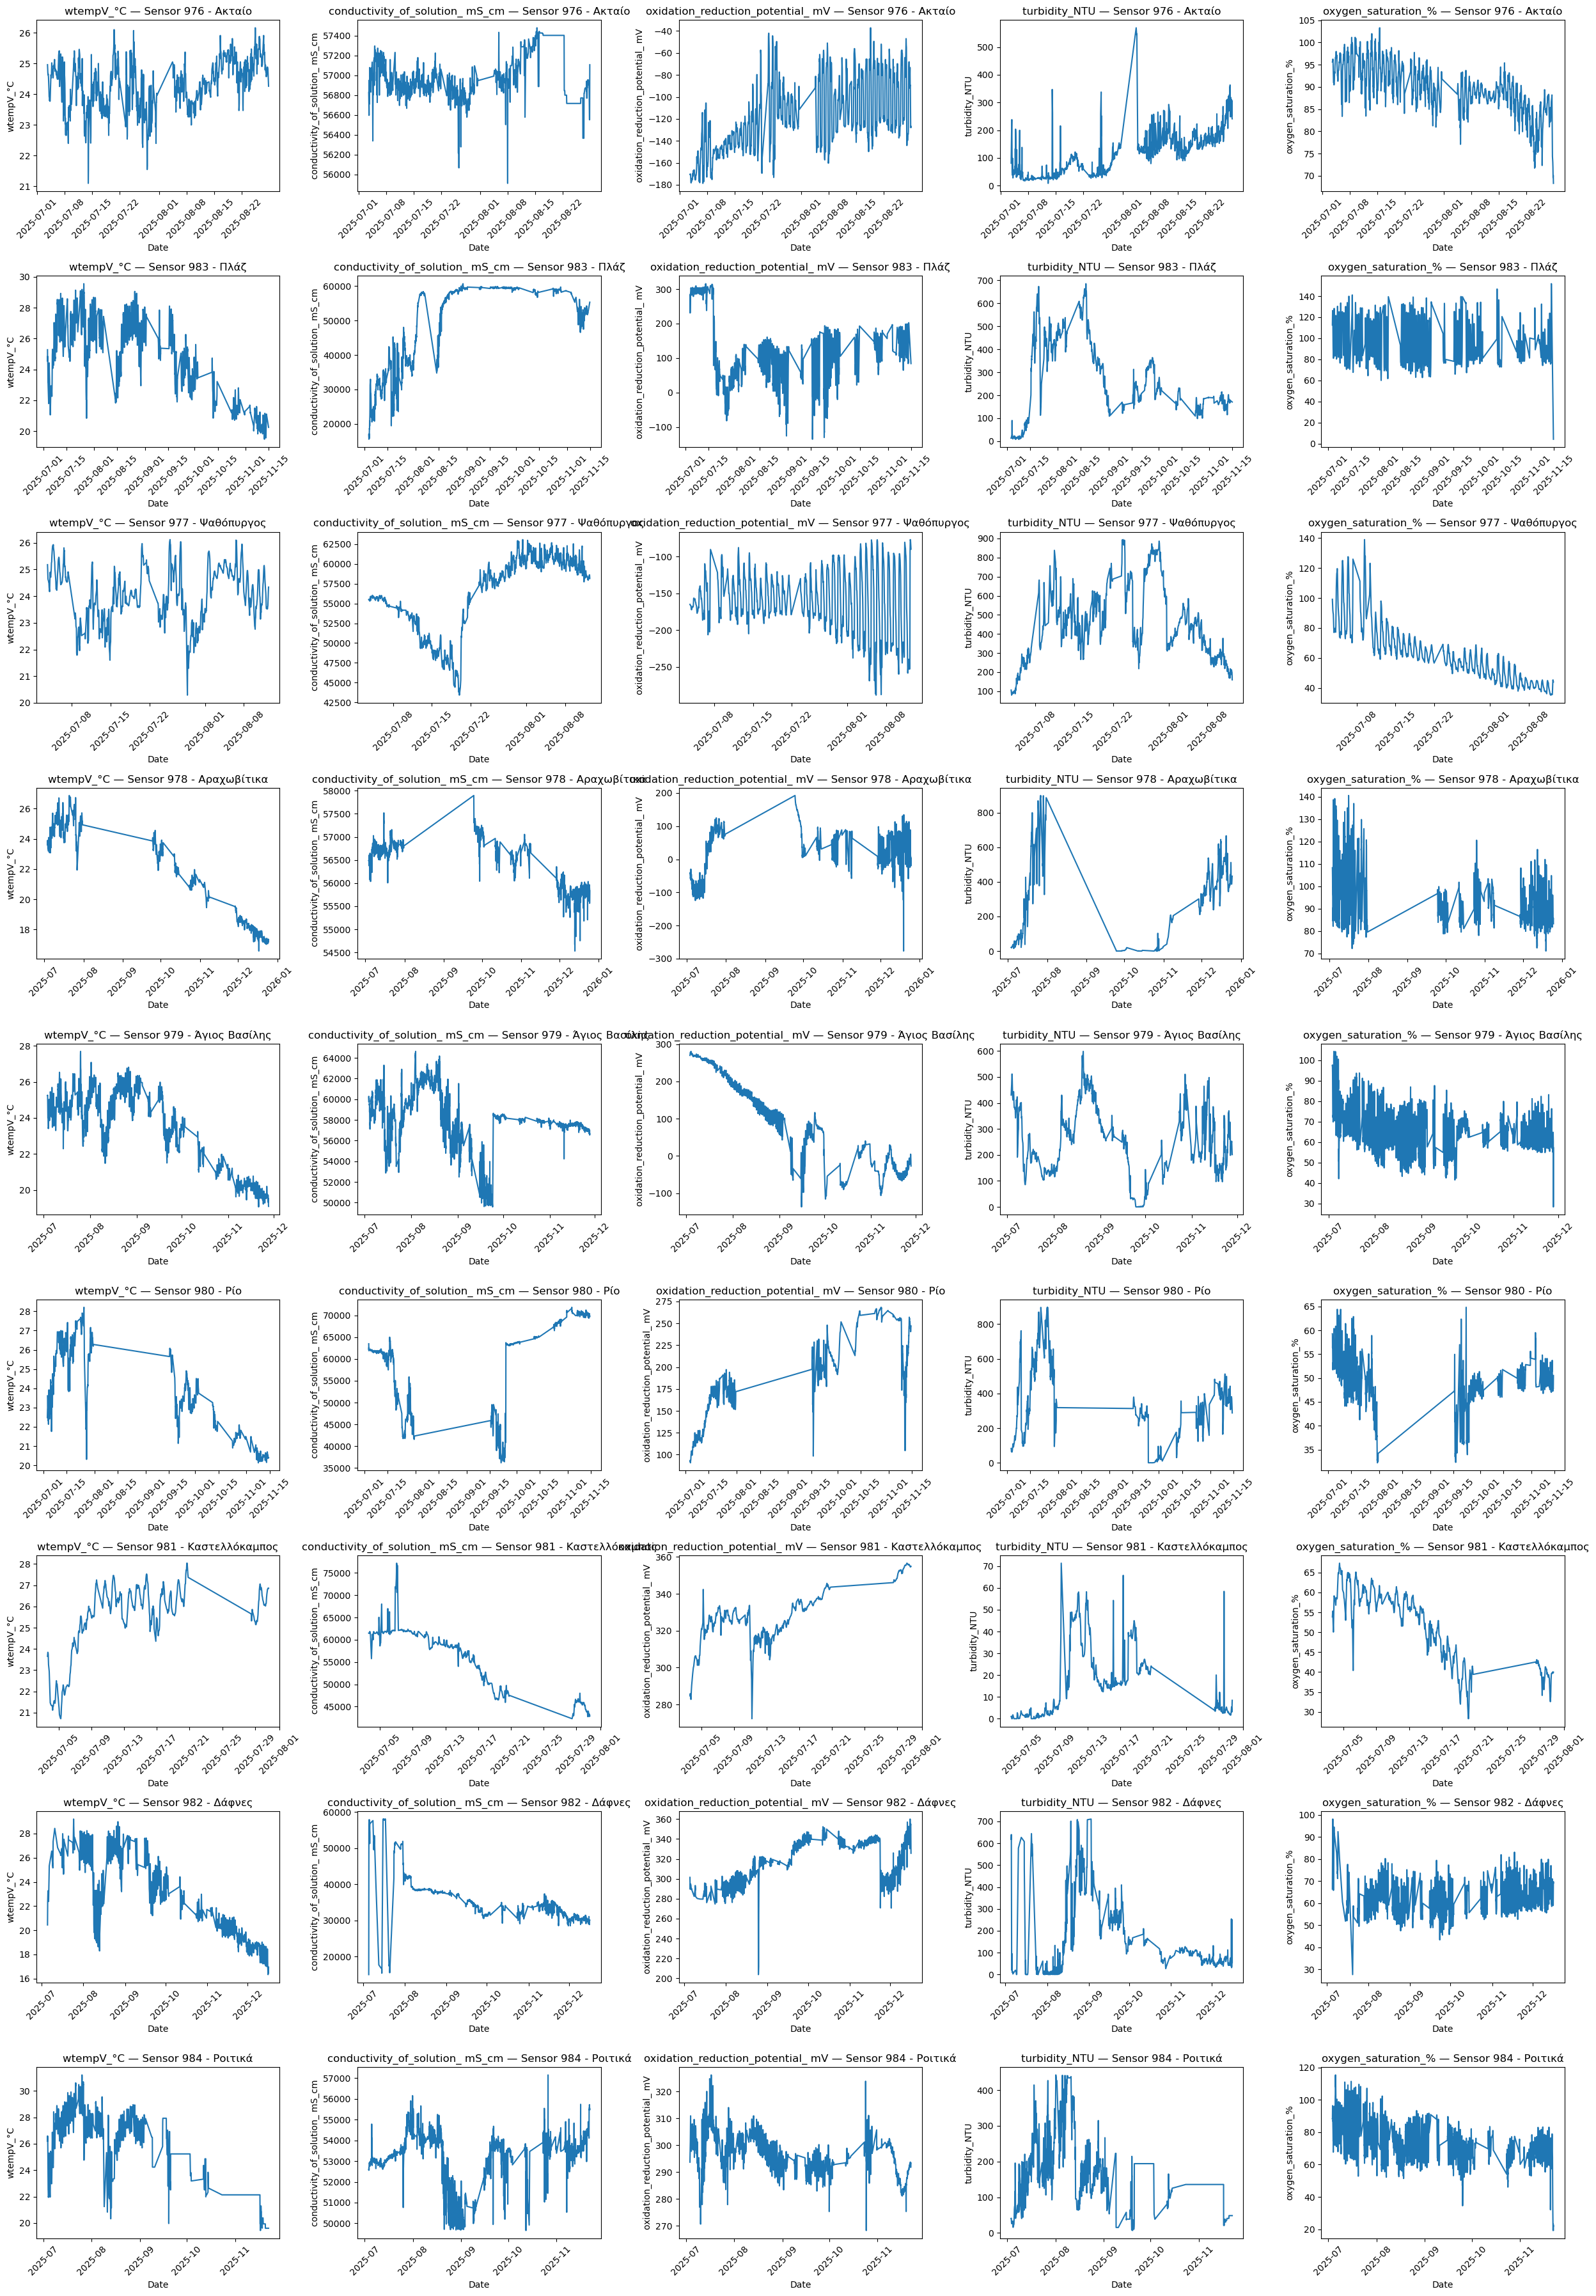

In [8]:
plot_sensors(list(df['sensor_id'].unique()),metrics,df_ready)

In [9]:
df_ready.to_csv(r"C:\Users\User\Desktop\water\data\cleaned_stats.csv")